In [1]:
%pip install numpy mne osl-dynamics tensorflow ipyevents ipywidgets pyvista pyvistaqt pandas seaborn nibabel nilearn scikit-image numba pyyaml scikit-learn

  Using cached mne-1.13.2-py3-none-any.whl.metadata (17 kB)
  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached ipyevents-2.0.4-py3-none-any.whl.metadata (3.0 kB)
  Using cached ipywidgets-8.1.9-py3-none-any.whl.metadata (2.4 kB)
  Using cached pyvista-0.49.0-py3-none-any.whl.metadata (14 kB)
  Using cached pyvistaqt-0.13.1-py3-none-any.whl.metadata (5.3 kB)
  Using cached nibabel-5.4.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached nilearn-0.14.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached scikit_image-0.26.0-cp312-cp312-win_amd64.whl.metadata (15 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
  Using cached scikit_learn-1.9.1-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached lazy_loader-0.6-py3-none-any.whl.metadata (6.0 kB)
  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached fslpy-3.29.1-py3-none-any.whl.metadat


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import sys
!conda run -n hmmnet pip install h5io


EnvironmentLocationNotFound: Not a conda environment: C:\Users\chick\miniforge3\envs\hmmnet



In [2]:
import mne
import numpy as np
import scipy.io
import h5py

from osl_dynamics import analysis, inference, files
from osl_dynamics.meeg import preproc, rhino, source_recon, parcellation
from osl_dynamics.data import Data
from osl_dynamics.utils import plotting
from osl_dynamics.utils.filenames import OSLFilenames


In [ ]:
import h5py
import numpy as np
import mne
import matplotlib.pyplot as plt
from scipy.signal import welch

# =============================================================================
# 1. LOAD DATA FROM MAT FILE
# =============================================================================

subject_folder = '//rdp.arc.ucl.ac.uk/ritd-ag-project-rd01pz-dbush99/Katja Button Press Data/s05/'
subject_filename = 'Subject5_spm_mne'

filepath = subject_folder + subject_filename + '.mat'

with h5py.File(filepath, 'r') as f:
    fid_pnt    = np.array(f['fid']['fid']['pnt']).T
    hsp_pnt    = np.array(f['fid']['pnt']).T
    data       = np.array(f['data']).T        # (n_channels, n_times)
    sfreq      = float(np.array(f['fs']).flatten()[0])
    chanpos    = np.array(f['sens']['chanpos']).T
    chanori    = np.array(f['sens']['chanori']).T
    chan_names = []
    for ref in f['chan_names'][:, 0]:
        name = ''.join(chr(c) for c in f[ref][:].flatten())
        chan_names.append(name)
    print(f['sens'])



print(f"Data shape: {data.shape}")
print(f"N channels: {len(chan_names)}")
print(f"Sampling rate: {sfreq} Hz")
print(f"EEG channel count: {len(eeg_names)}")
print(f"EEG data shape: {data_eeg.shape}")
print(eeg_names)

<HDF5 group "/sens" (13 members)>
Data shape: (341, 14801, 240)
N channels: 341
Sampling rate: 1000.0 Hz
EEG channel count: 4
EEG data shape: (4, 14801, 240)
['EEG057', 'EEG058', 'EEG059', 'EEG060']


In [22]:
# =============================================================================
# 2. BUILD MNE RAW OBJECT
# =============================================================================
# Load CTF file for correct channel info (positions, coil types, dev_head_t)
raw_ctf = mne.io.read_raw_ctf(
    '//rdp.arc.ucl.ac.uk/ritd-ag-project-rd01pz-dbush99/Katja Button Press Data/s05/mg4670_katja2_20160623_01.ds',
    preload=False
)

# Strip CTF serial number suffix
ctf_ch_names_stripped = [ch.split('-')[0] for ch in raw_ctf.ch_names]

# Reorder SPM data to match CTF channel order and convert fT → T

spm_to_ctf_idx = [chan_names.index(ch) for ch in ctf_ch_names_stripped]
data_meg = data[spm_to_ctf_idx, :] / 1e15   # (273, n_times) in Tesla

eeg_idx = [i for i, name in enumerate(chan_names) if name.startswith("EEG")]


eeg_names = [chan_names[i] for i in eeg_idx]

data_eeg = data[eeg_idx, :]
print(f"EEG data shape: {data_eeg.shape}")

# reorder data_eeg to have shape (n_epochs/trials, n_channels, n_times)
data_eeg = data_eeg.transpose(1, 0, 2)
print("Reordered data_eeg shape:", data_eeg.shape)

# Reorder chanpos to match CTF channel order
##### chanpos_meg = chanpos[spm_to_ctf_idx, :]

print(f"data_meg shape: {data_meg.shape}")
print(f"data_meg std: {data_meg.std():.2e}")  # should be ~1e-13

print(f"EEG channel count: {len(eeg_names)}")
print(f"EEG data shape: {data_eeg.shape}")

# Create Raw using CTF info (has correct positions, coil types, dev_head_t)
##### raw = mne.io.RawArray(data_meg, raw_ctf.info)

info = mne.create_info(
    ch_names=eeg_names,
    sfreq=sfreq,
    ch_types=["eeg"] * len(eeg_names),
)

Epochs_data_array = mne.EpochsArray(data_eeg, info)

print(f"dev_head_t: {Epochs_data_array.info['dev_head_t']}")

ds directory : \\rdp.arc.ucl.ac.uk\ritd-ag-project-rd01pz-dbush99\Katja Button Press Data\s05\mg4670_katja2_20160623_01.ds
    res4 data read.
    hc data read.
    Separate EEG position data file read.
    Quaternion matching (desired vs. transformed):
      -0.02   76.26    0.00 mm <->   -0.02   76.26   -0.00 mm (orig :  -47.05   64.14 -266.25 mm) diff =    0.000 mm
       0.02  -76.26    0.00 mm <->    0.02  -76.26    0.00 mm (orig :   55.90  -47.62 -279.35 mm) diff =    0.000 mm
      99.56    0.00    0.00 mm <->   99.56   -0.00   -0.00 mm (orig :   77.83   74.42 -260.68 mm) diff =    0.000 mm
    Coordinate transformations established.
    Polhemus data for 3 HPI coils added
    Device coordinate locations for 3 HPI coils added
    4 EEG electrode locations assigned to channel info.
    4 EEG locations added to Polhemus data.
    Measurement info composed.
Finding samples for \\rdp.arc.ucl.ac.uk\ritd-ag-project-rd01pz-dbush99\Katja Button Press Data\s05\mg4670_katja2_20160623_01.d

In [24]:
# =============================================================================
# 3. SAVE
# =============================================================================
import os

os.chdir(subject_folder)        
outfile = subject_folder + subject_filename + '.fif'
Epochs_data_array.save(outfile, overwrite=True)
print("Saved!")


C:\Users\chick\AppData\Local\Temp\ipykernel_33404\3061489649.py:8: RuntimeWarning: This filename (//rdp.arc.ucl.ac.uk/ritd-ag-project-rd01pz-dbush99/Katja Button Press Data/s05/Subject5_spm_mne.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  Epochs_data_array.save(outfile, overwrite=True)


Saved!


Reading \\rdp.arc.ucl.ac.uk\ritd-ag-project-rd01pz-dbush99\Katja Button Press Data\s05\Subject5_spm_mne.fif ...


C:\Users\chick\AppData\Local\Temp\ipykernel_33404\514856087.py:1: RuntimeWarning: This filename (//rdp.arc.ucl.ac.uk/ritd-ag-project-rd01pz-dbush99/Katja Button Press Data/s05/Subject5_spm_mne.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_vis = mne.read_epochs(outfile, preload=True)


Isotrak not found
    Found the data of interest:
        t =       0.00 ...     239.00 ms
        0 CTF compensation matrices available
Not setting metadata
14801 matching events found
No baseline correction applied
0 projection items activated
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


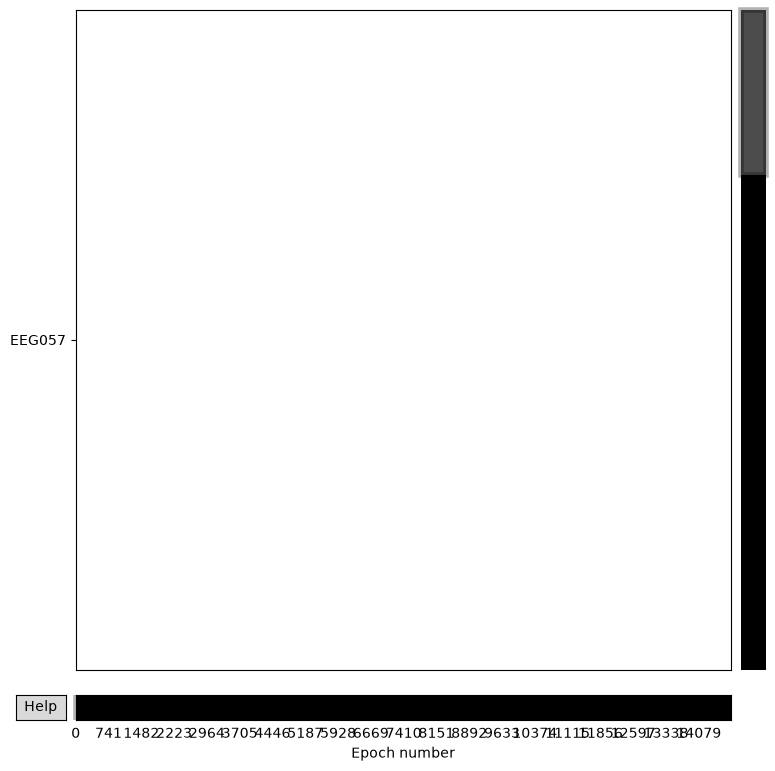

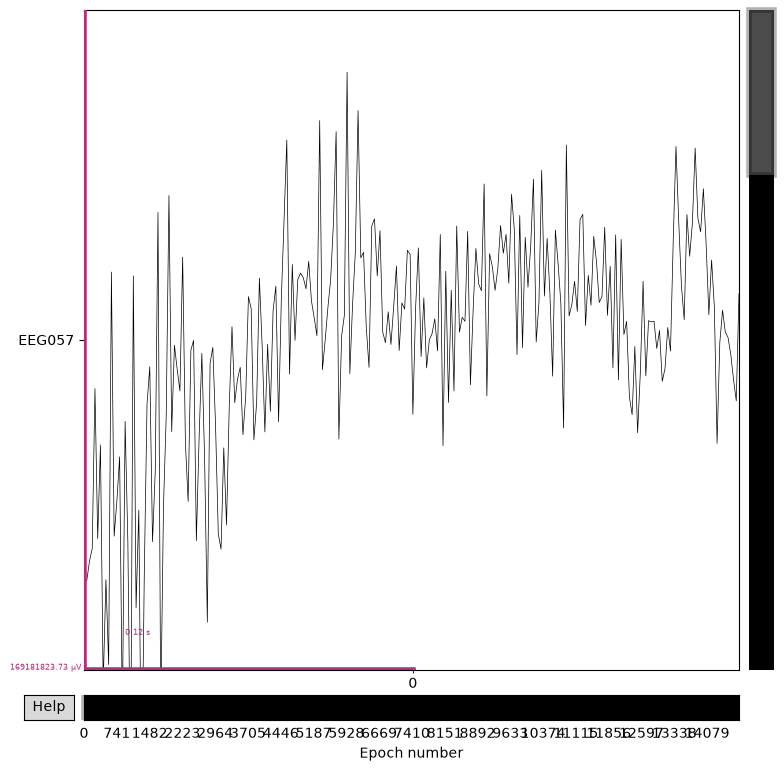

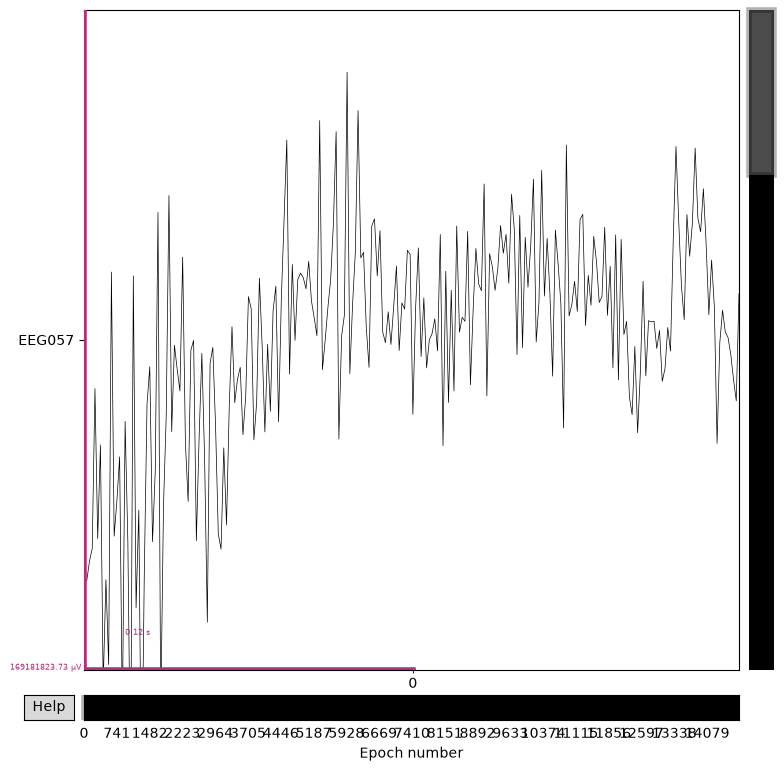

In [29]:
epochs_vis = mne.read_epochs(outfile, preload=True)
epochs_vis.plot(
    n_epochs=1,
    n_channels=1,
    scalings="auto",
)